In [1]:
# %matplotlib widget
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import ngspice_raw_read as ngr

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 4), sharex=True)

corners = {
    "tt": mos_tt.df,
    "ff": mos_ff.df,
    "ss": mos_ss.df,
}

for name, df in corners.items():
    time_us = df["time"] * 1e6
    freq_mhz = df["f"].iloc[0] * 1e-6

    # Frequency is shown in the legend instead of in separate subplot titles
    ax[0].plot(
        time_us,
        df["v(ro_raw)"],
        lw=1,
        label=f"{name}, f={freq_mhz:.1f} MHz",
    )

ax[0].set_title("RO output across corners")
ax[0].set_ylabel("v(ro_raw) / V")
ax[0].set_xlim(0.05, 0.07)
ax[0].legend()

x = mos_tt.df["time"] * 1e6

# Enable signals are usually identical/control signals, so plotting one corner is often enough
ax[1].plot(x, mos_tt.df["v(en)"] + 2, label="v(en) + 2 V")
ax[1].plot(x, mos_tt.df["v(en_n)"], label="v(en_n)")
ax[1].set_title("Enable signals")
ax[1].set_xlabel("time / µs")
ax[1].set_ylabel("voltage / V")
ax[1].legend()

fig.tight_layout()


# DIV16

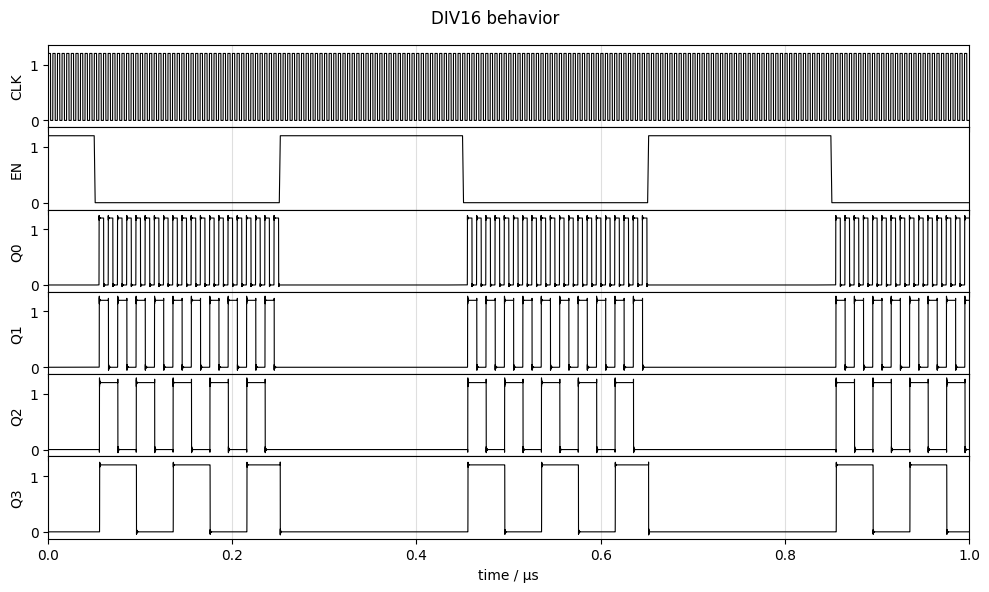

In [8]:
div16raw = "digital/div16/xschem/simulation/div16-tb.raw"
div16 = ngr.Ngraw(div16raw, pv=False)

x = div16.df["time"] * 1e6

signals = [
    ("CLK", "v(clk)"),
    ("EN",  "v(en_n)"),
    ("Q0",  "v(q0)"),
    ("Q1",  "v(q1)"),
    ("Q2",  "v(q2)"),
    ("Q3",  "v(q3)"),
]

fig, ax = plt.subplots(
    ncols=1,
    nrows=len(signals),
    figsize=(10, 6),
    sharex=True,
    sharey=True,
    gridspec_kw={"hspace": 0},
)

for a, (label, col) in zip(ax, signals):
    a.plot(x, div16.df[col], lw=0.8, color='black')
    a.set_ylabel(label)
    a.grid(True, axis="x", alpha=0.4)
    a.margins(x=0)

ax[-1].set_xlabel("time / µs")

fig.suptitle("DIV16 behavior")

plt.tight_layout()

# OCTS Intermediate Signals at 25C

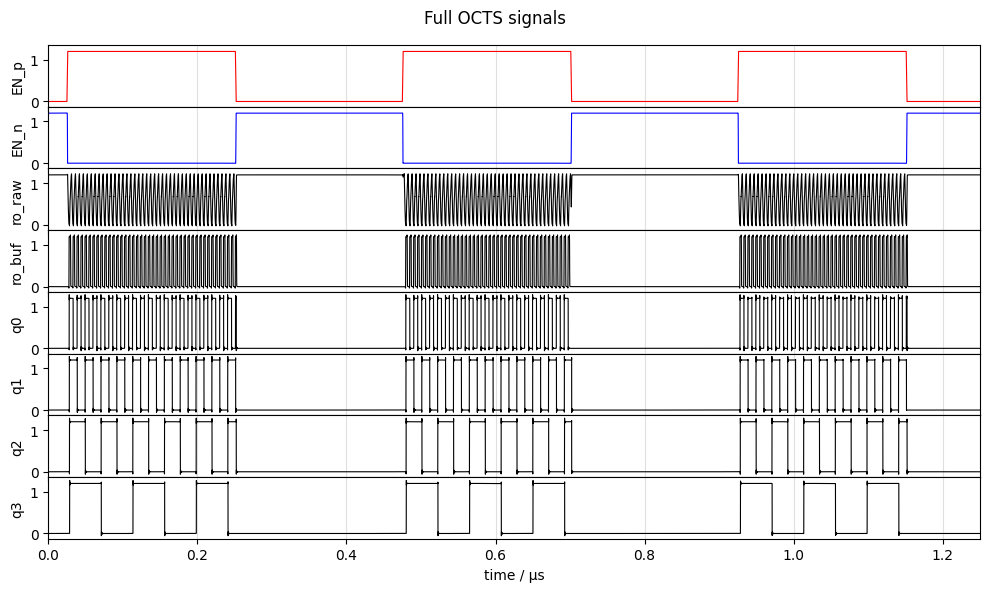

In [5]:
octs_full_raw = "octs-full/simulation/octs-full-tb.raw"
octs_full = ngr.Ngraw(octs_full_raw, pv=False)

x = octs_full.df["time"] * 1e6

signals = [
    ("EN_p", "v(en)"),
    ("EN_n", "v(en_n)"),
    ("ro_raw", "v(ro_raw)"),
    ("ro_buf", "v(ro_buf)"),
    ("q0", "v(q0)"),
    ("q1", "v(q1)"),
    ("q2", "v(q2)"),
    ("q3", "v(q3)"),
]

fig, ax = plt.subplots(
    ncols=1,
    nrows=len(signals),
    figsize=(10, 6),
    sharex=True,
    sharey=True,
    gridspec_kw={"hspace": 0},
)

for a, (label, col) in zip(ax, signals):
    if label == "EN_p":
        a.plot(x, octs_full.df[col], lw=0.8, color='red')
    elif label == "EN_n":
        a.plot(x, octs_full.df[col], lw=0.8, color='blue')
    else:
        a.plot(x, octs_full.df[col], lw=0.8, color='black')
    a.set_ylabel(label)
    a.grid(axis="x", alpha=0.4)
    a.margins(x=0)

ax[-1].set_xlabel("time / µs")
ax[-1].set_xlim(0, 1.25)

fig.suptitle("Full OCTS signals")

plt.tight_layout()
plt.savefig("octs-full-tb.svg")
plt.show()

# Monte-Carlo Device Mismatch Temperature Sweep, 100 Runs

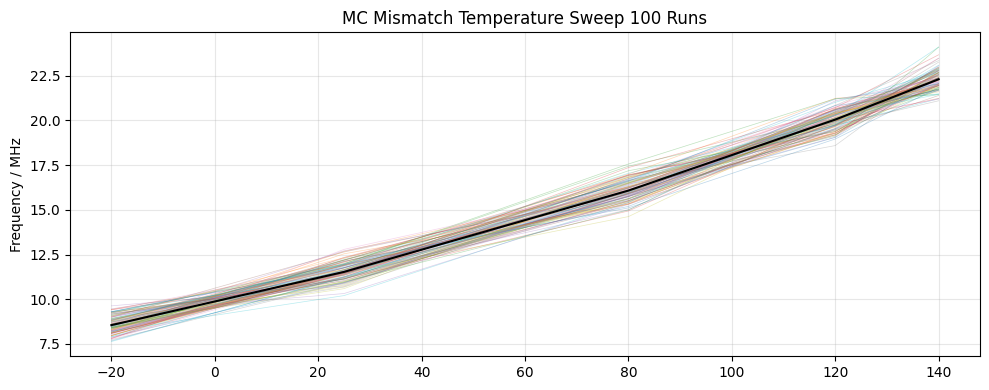

In [11]:
mismatchtsweep_csv = "octs-full/simulation/octs-full-tb-mc-mismatch-tsweep/octs-full-tb_result.csv"
mismatchtsweep_csv_path, mismatchtsweep_csv_file_name = os.path.split(mismatchtsweep_csv)

with open(mismatchtsweep_csv, 'r') as f:
    mmtsweep = pd.read_csv(f)

p = mmtsweep.pivot(index="temperature", columns="run", values="tp_q3").sort_index()

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(10,4), sharex=True, clear=True)
ax.plot(
    1/p * 1e-6,
    alpha=.3,
    lw=0.5
)
ax.plot(
    1/p.mean(axis=1) * 1e-6,
    color='black',
    label='mean'
)

ax.set_title("MC Mismatch Temperature Sweep 100 Runs")
ax.set_ylabel("Frequency / MHz")
ax.grid(alpha=.3)

plt.tight_layout()
plt.savefig("mm25c.svg")
plt.show()

For each temperature compute:

$$ \frac{\sigma_f}{\mu_f}$$

y-axis is relative MC spread.

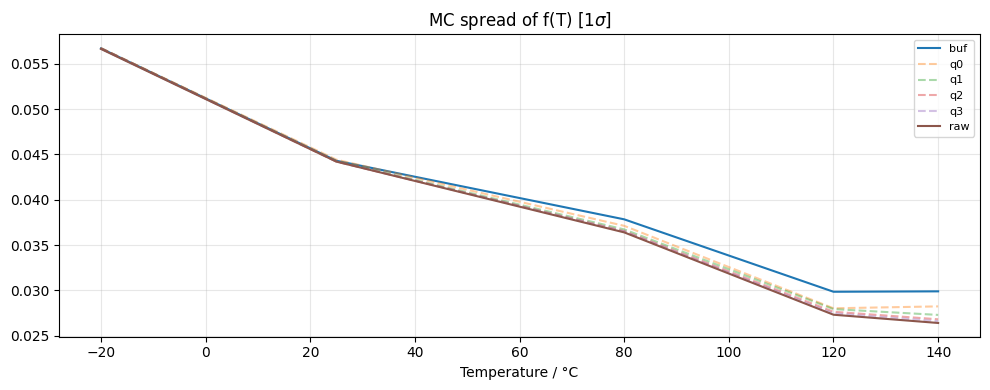

In [12]:
tp_cols = [c for c in mmtsweep.columns if c.startswith("tp_")]

# Long format
d = mmtsweep.melt(
    id_vars=["run", "temperature"],
    value_vars=tp_cols,
    var_name="signal",
    value_name="period"
)

d["freq"] = 1 / d["period"] * 1e-6

# Spread across MC runs at each temperature
spread = (
    d.groupby(["temperature", "signal"])["freq"]
     .agg(mean="mean", std="std")
     .reset_index()
)

spread["rel_std"] = spread["std"] / spread["mean"]

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

for sig, g in spread.groupby("signal"):
    if sig == "tp_buf" or sig == "tp_raw":
        ax.plot(g["temperature"], g["rel_std"], label=sig.replace("tp_", ""))
    else:
        ax.plot(g["temperature"], g["rel_std"], label=sig.replace("tp_", ""), ls='--', alpha=.4)

ax.set_title(r"MC spread of f(T) [1$\sigma$]")
ax.set_xlabel("Temperature / °C")
# ax.set_ylabel("f / MHz")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("mmtsweep.svg")
plt.show()


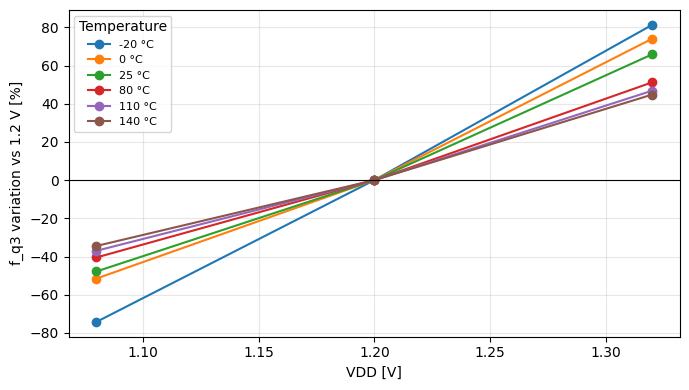

In [17]:
pvt_csv = "octs-full/simulation/octs-full-tb-pvt_2026-06-20_18-28-59/octs-full-tb_result.csv"
pvt_csv_path, pvt_csv_file_name = os.path.split(pvt_csv)

with open(pvt_csv, 'r') as f:
    pvt = pd.read_csv(f)

sig = "f_q3"       # change to f_buf, f_q0, ...
vdd_nom = 1.20

ref = (
    pvt[pvt["param_vdd"].eq(vdd_nom)]
    [["temperature", sig]]
    .rename(columns={sig: "f_ref"})
)

d = pvt.merge(ref, on="temperature")
d["df_vdd_pct"] = (d[sig] / d["f_ref"] - 1) * 100

fig, ax = plt.subplots(figsize=(7, 4))

for temp, g in d.groupby("temperature"):
    ax.plot(g["param_vdd"], g["df_vdd_pct"], marker="o", label=f"{temp} °C")

ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("VDD [V]")
ax.set_ylabel(f"{sig} variation vs 1.2 V [%]")
ax.grid(True, alpha=0.3)
ax.legend(title="Temperature", fontsize=8)

plt.tight_layout()
plt.show()

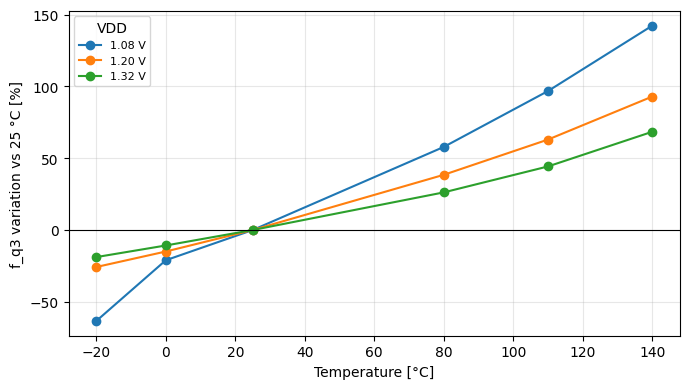

In [18]:
temp_nom = 25

ref = (
    pvt[pvt["temperature"].eq(temp_nom)]
    [["param_vdd", sig]]
    .rename(columns={sig: "f_ref"})
)

d = pvt.merge(ref, on="param_vdd")
d["df_temp_pct"] = (d[sig] / d["f_ref"] - 1) * 100

fig, ax = plt.subplots(figsize=(7, 4))

for vdd, g in d.groupby("param_vdd"):
    ax.plot(g["temperature"], g["df_temp_pct"], marker="o", label=f"{vdd:.2f} V")

ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Temperature [°C]")
ax.set_ylabel(f"{sig} variation vs 25 °C [%]")
ax.grid(True, alpha=0.3)
ax.legend(title="VDD", fontsize=8)

plt.tight_layout()
plt.show()
